In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prices_0 = pd.read_csv("data/prices_round_3_day_0.csv", delimiter=';')
prices_1 = pd.read_csv("data/prices_round_3_day_1.csv", delimiter=';')
prices_2 = pd.read_csv("data/prices_round_3_day_2.csv", delimiter=';')

trades_0 = pd.read_csv("data/trades_round_3_day_0.csv", delimiter=';')
trades_1 = pd.read_csv("data/trades_round_3_day_1.csv", delimiter=';')
trades_2 = pd.read_csv("data/trades_round_3_day_2.csv", delimiter=';')

OFFSET = 1_000_000

prices_0['global_timestamp'] = prices_0['timestamp'] + 0 * OFFSET
prices_1['global_timestamp'] = prices_1['timestamp'] + 1 * OFFSET
prices_2['global_timestamp'] = prices_2['timestamp'] + 2 * OFFSET

prices_all = pd.concat([prices_0, prices_1, prices_2], ignore_index=True).sort_values('global_timestamp').reset_index(drop=True)
print(prices_all.shape)
prices_all.head()

(360000, 18)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0
1,0,0,VEV_6000,0,25,NaN,NaN,NaN,NaN,1,25,NaN,NaN,NaN,NaN,0.5,0.0,0
2,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,19,NaN,NaN,NaN,NaN,171.5,0.0,0
3,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0,0
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0


In [3]:
# Extract HYDROGEL_PACK data
hg = prices_all[prices_all['product'] == 'HYDROGEL_PACK'].copy().reset_index(drop=True)
hg['spread'] = hg['ask_price_1'] - hg['bid_price_1']
hg['mid'] = (hg['bid_price_1'] + hg['ask_price_1']) / 2

# Separate by day
hg_days = {d: hg[hg['day'] == d].copy() for d in hg['day'].unique()}
colors = ['steelblue', 'darkorange', 'seagreen']

print(f"Total ticks: {len(hg)}")
print(f"Days: {sorted(hg['day'].unique())}")
print(f"\nMid price stats:")
print(hg['mid'].describe())
print(f"\nSpread stats:")
print(hg['spread'].describe())
hg.head()

Total ticks: 30000
Days: [0, 1, 2]

Mid price stats:
count    30000.000000
mean      9990.806867
std         31.935214
min       9891.000000
25%       9967.500000
50%       9994.000000
75%      10013.000000
max      10079.000000
Name: mid, dtype: float64

Spread stats:
count    30000.000000
mean        15.720800
std          1.455032
min          7.000000
25%         16.000000
50%         16.000000
75%         16.000000
max         17.000000
Name: spread, dtype: float64


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp,spread,mid
0,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0,16,10000.0
1,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,100,16,10000.0
2,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,200,16,10003.0
3,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0,300,16,10002.0
4,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0,400,16,10003.0


## 1. Price Behaviour

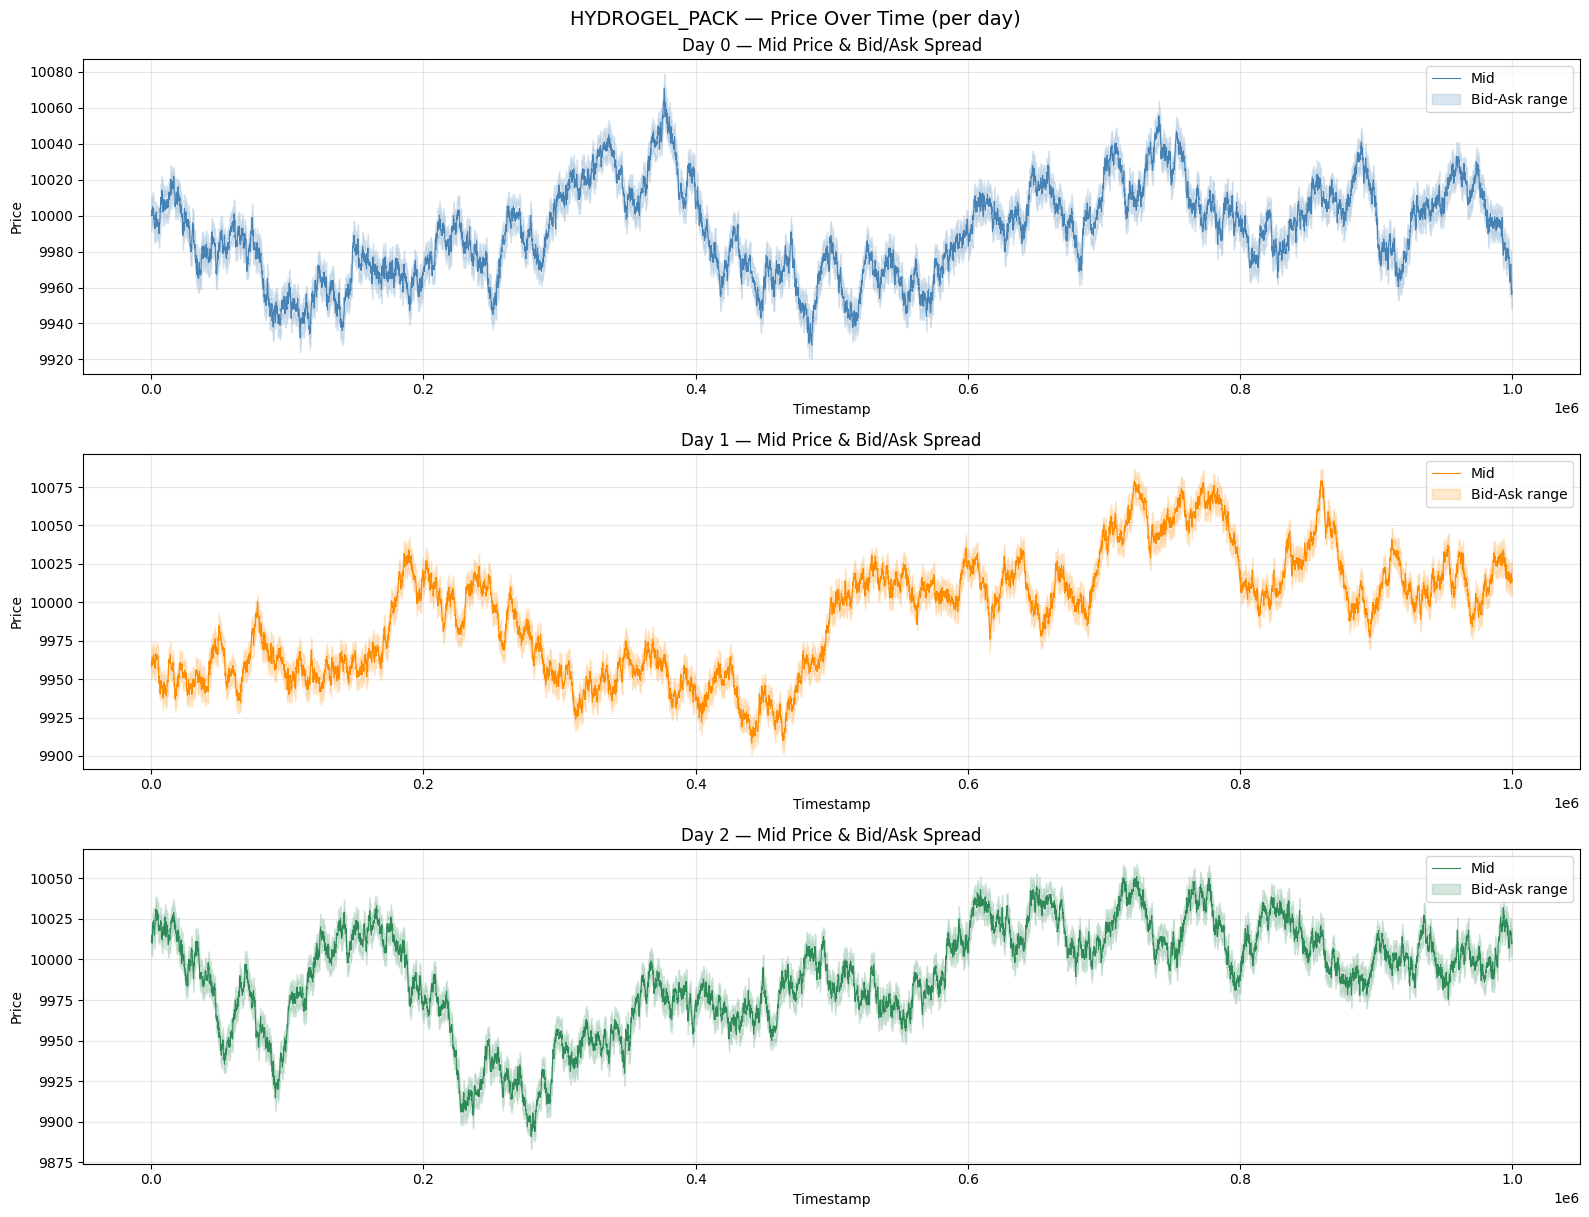

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for i, (day, df) in enumerate(sorted(hg_days.items())):
    ax = axes[i]
    ax.plot(df['timestamp'], df['mid'], color=colors[i], linewidth=0.8, label='Mid')
    ax.fill_between(df['timestamp'], df['bid_price_1'], df['ask_price_1'],
                    alpha=0.2, color=colors[i], label='Bid-Ask range')
    ax.set_title(f"Day {day} — Mid Price & Bid/Ask Spread")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("HYDROGEL_PACK — Price Over Time (per day)", y=1.01, fontsize=14)
plt.show()

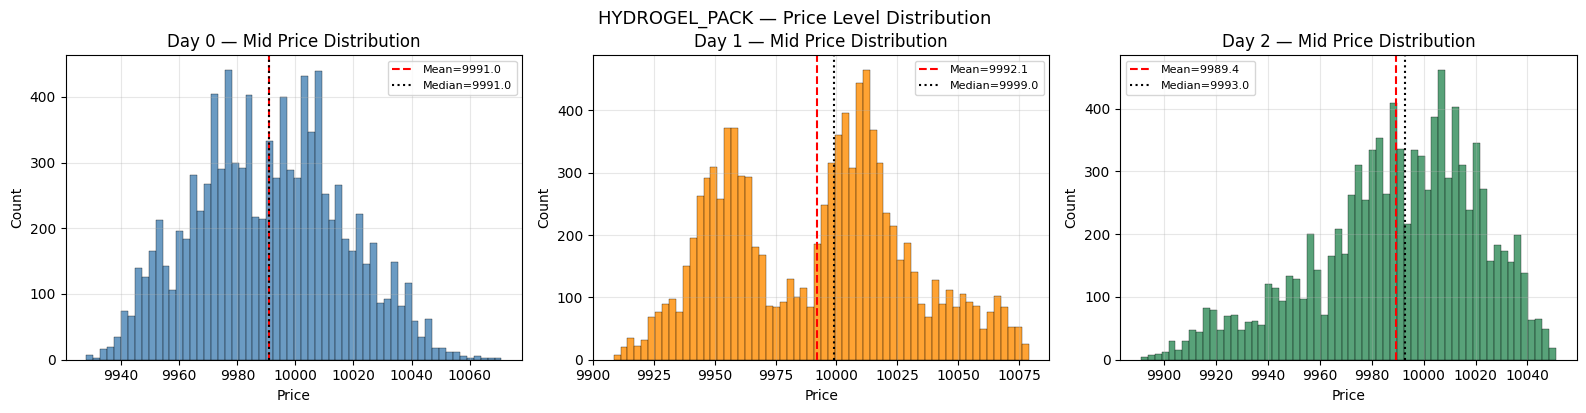

Tick-to-tick return stats:
count    29997.000000
mean         0.000467
std          2.169826
min        -11.500000
25%         -1.000000
50%          0.000000
75%          1.000000
max         11.500000
Name: mid_return, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (day, df) in enumerate(sorted(hg_days.items())):
    ax = axes[i]
    ax.hist(df['mid'], bins=60, color=colors[i], edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.axvline(df['mid'].mean(), color='red', linestyle='--', label=f"Mean={df['mid'].mean():.1f}")
    ax.axvline(df['mid'].median(), color='black', linestyle=':', label=f"Median={df['mid'].median():.1f}")
    ax.set_title(f"Day {day} — Mid Price Distribution")
    ax.set_xlabel("Price")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("HYDROGEL_PACK — Price Level Distribution", y=1.02, fontsize=13)
plt.show()

hg['mid_return'] = hg.groupby('day')['mid'].diff()
print("Tick-to-tick return stats:")
print(hg['mid_return'].describe())

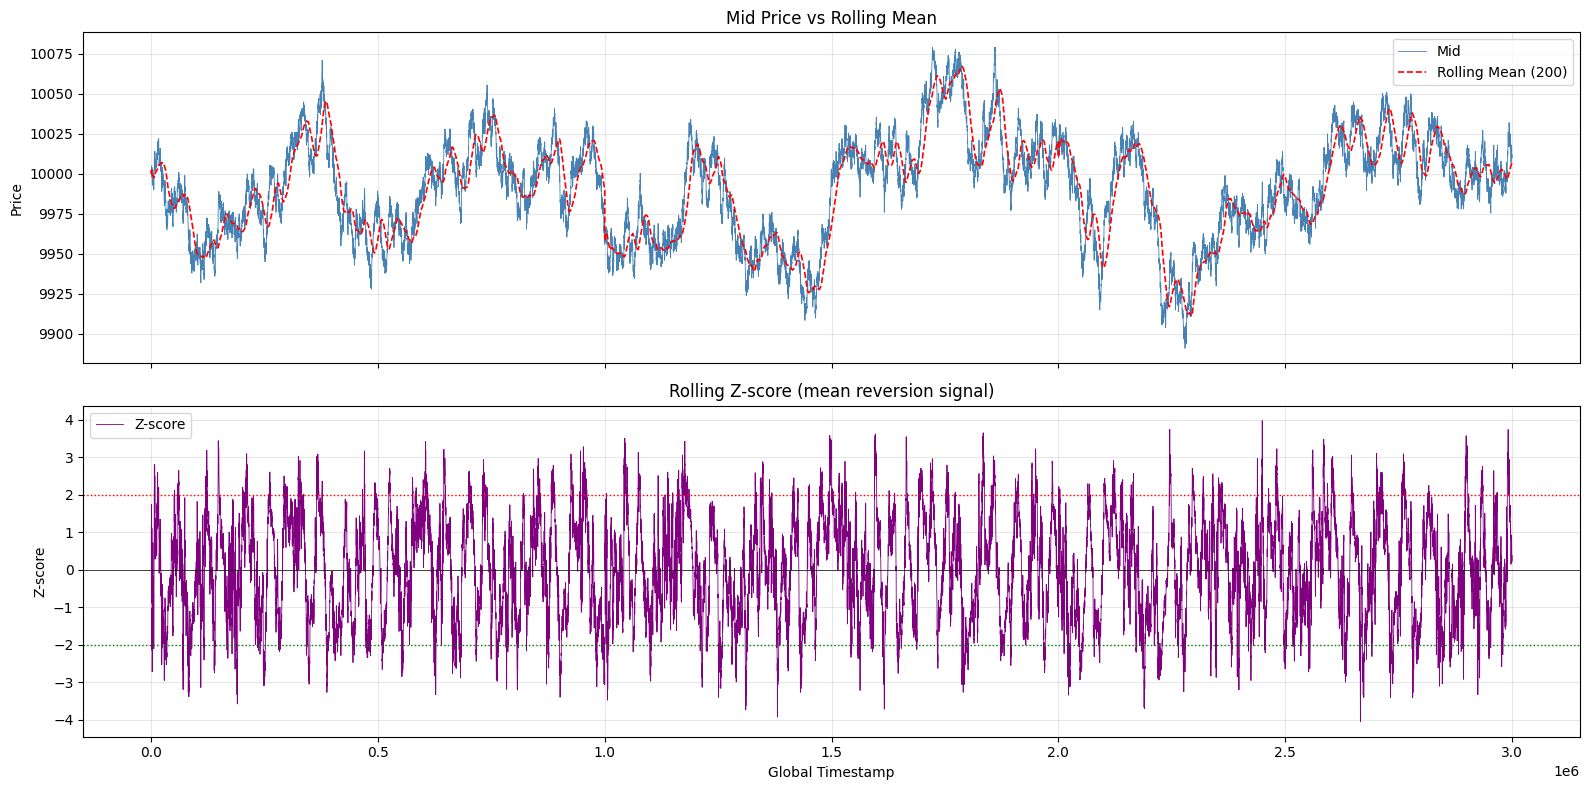

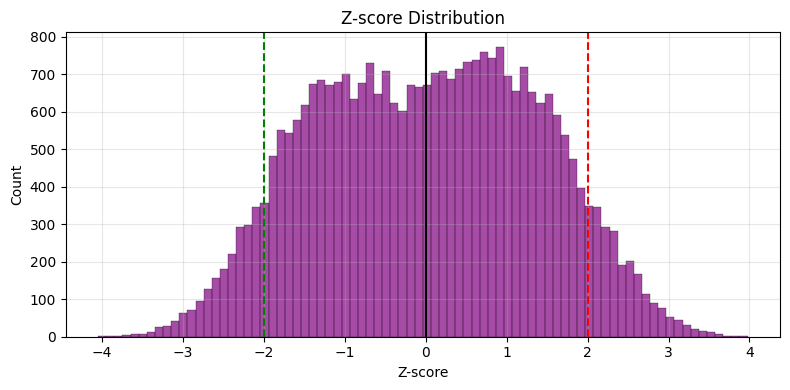

Ticks with |z| > 2: 4315 (14.4%)


In [6]:
# Rolling z-score
WINDOW = 200
hg['rolling_mean'] = hg.groupby('day')['mid'].transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
hg['rolling_std']  = hg.groupby('day')['mid'].transform(lambda x: x.rolling(WINDOW, min_periods=2).std())
hg['z_score'] = (hg['mid'] - hg['rolling_mean']) / hg['rolling_std'].replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(hg['global_timestamp'], hg['mid'], linewidth=0.6, color='steelblue', label='Mid')
axes[0].plot(hg['global_timestamp'], hg['rolling_mean'], linewidth=1.2, color='red', linestyle='--', label=f'Rolling Mean ({WINDOW})')
axes[0].set_ylabel("Price"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Mid Price vs Rolling Mean")

axes[1].plot(hg['global_timestamp'], hg['z_score'], linewidth=0.6, color='purple', label='Z-score')
axes[1].axhline(2, color='red', linestyle=':', linewidth=1)
axes[1].axhline(-2, color='green', linestyle=':', linewidth=1)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel("Z-score"); axes[1].set_xlabel("Global Timestamp"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Rolling Z-score (mean reversion signal)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hg['z_score'].dropna(), bins=80, color='purple', alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black'); ax.axvline(2, color='red', linestyle='--'); ax.axvline(-2, color='green', linestyle='--')
ax.set_xlabel("Z-score"); ax.set_ylabel("Count"); ax.set_title("Z-score Distribution")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Ticks with |z| > 2: {(hg['z_score'].abs() > 2).sum()} ({(hg['z_score'].abs() > 2).mean()*100:.1f}%)")

## 2. Microstructure Features

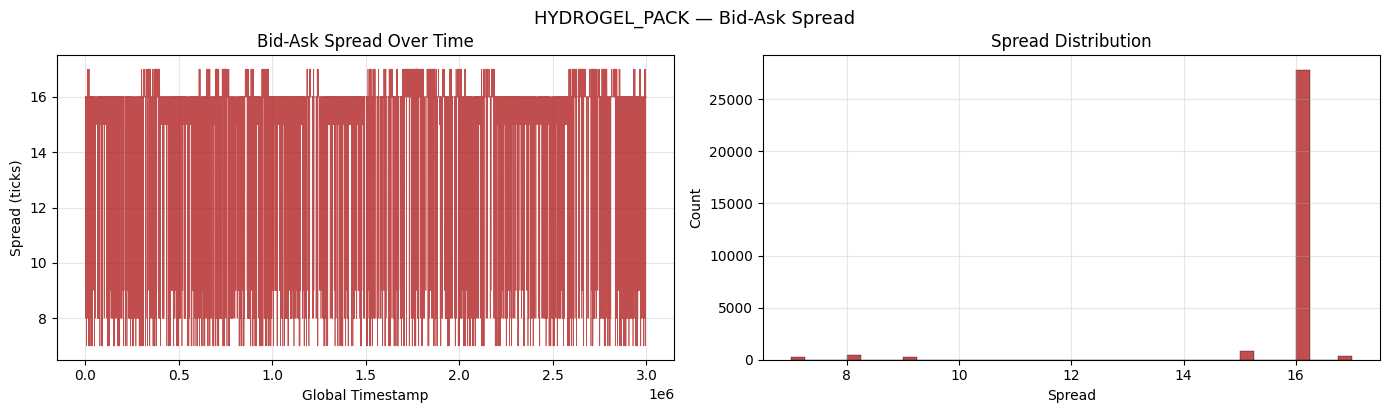

Spread value counts (most common):
spread
16    27820
15      798
8       490
17      392
7       275
9       225
Name: count, dtype: int64

Mean spread: 15.721
Spread = 1 tick: 0.0%
Spread = 2 ticks: 0.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hg['global_timestamp'], hg['spread'], linewidth=0.5, color='firebrick', alpha=0.8)
axes[0].set_title("Bid-Ask Spread Over Time")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("Spread (ticks)"); axes[0].grid(alpha=0.3)

axes[1].hist(hg['spread'].dropna(), bins=40, color='firebrick', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title("Spread Distribution")
axes[1].set_xlabel("Spread"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("HYDROGEL_PACK — Bid-Ask Spread", y=1.02, fontsize=13)
plt.show()

print("Spread value counts (most common):")
print(hg['spread'].value_counts().head(10))
print(f"\nMean spread: {hg['spread'].mean():.3f}")
print(f"Spread = 1 tick: {(hg['spread'] == 1).mean()*100:.1f}%")
print(f"Spread = 2 ticks: {(hg['spread'] == 2).mean()*100:.1f}%")

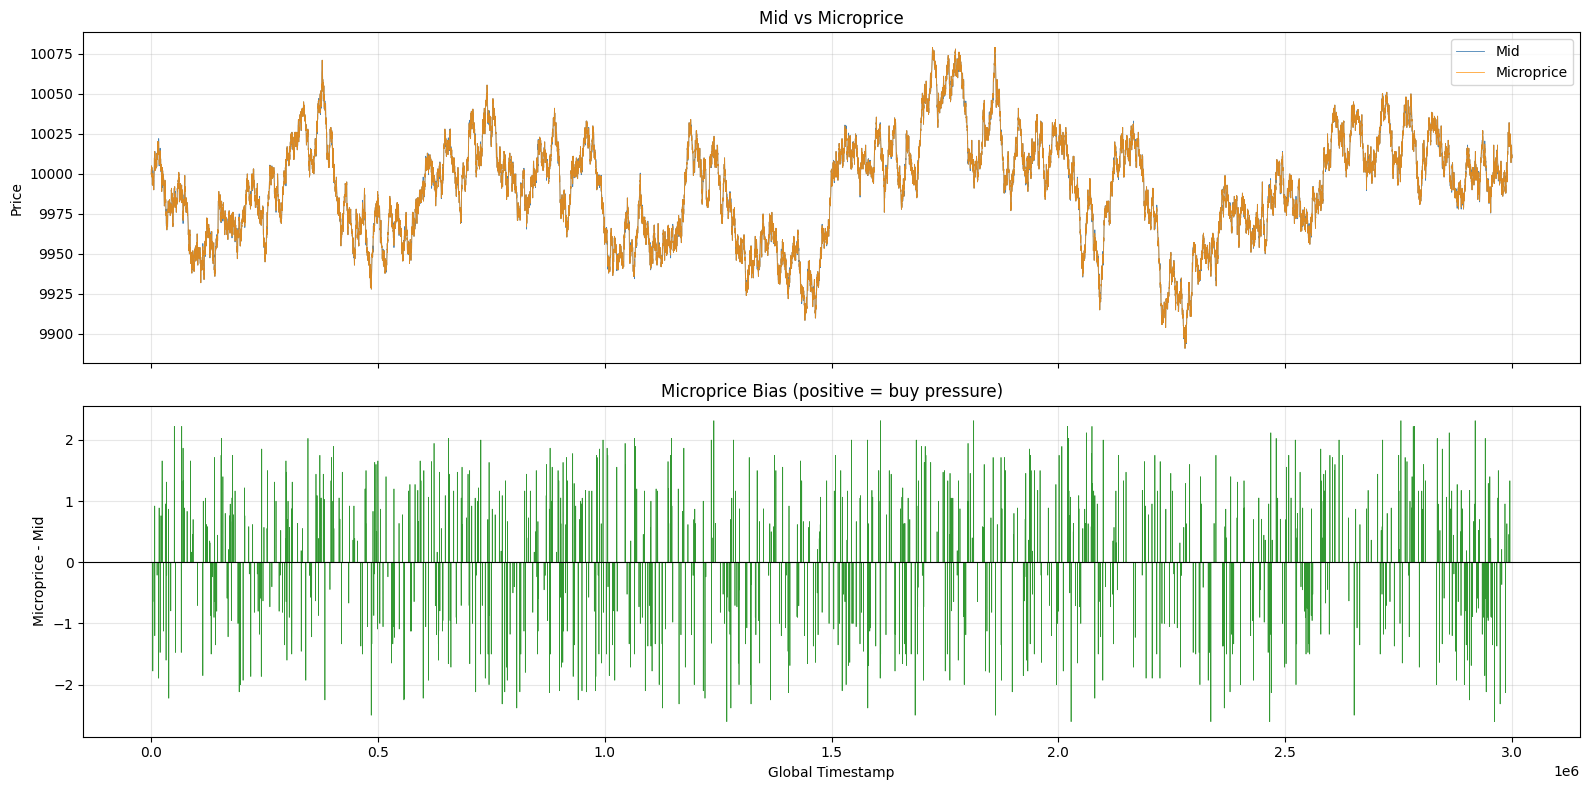

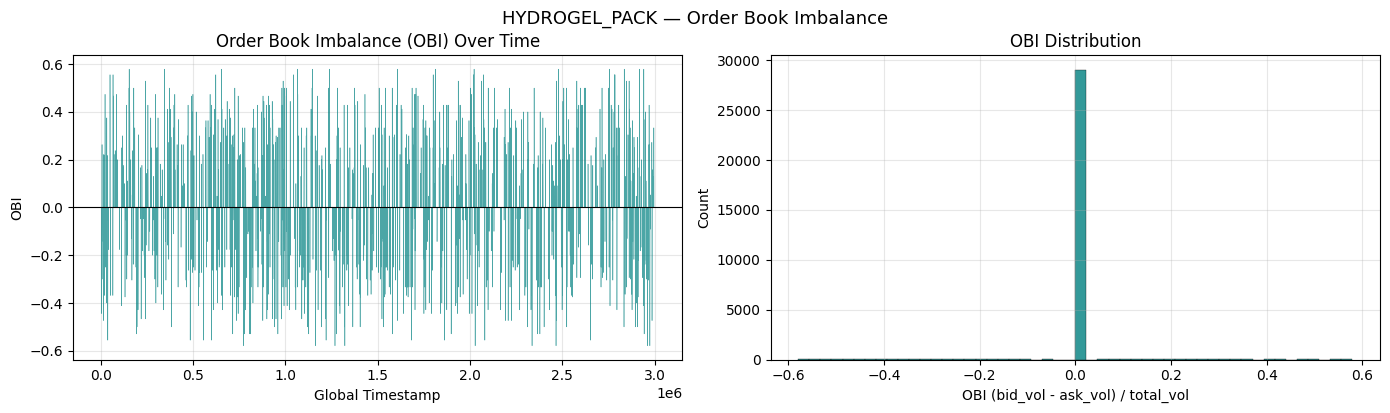

OBI stats:
count    30000.000000
mean         0.000511
std          0.057940
min         -0.578947
25%          0.000000
50%          0.000000
75%          0.000000
max          0.578947
Name: obi, dtype: float64


In [8]:
# Microprice
hg['microprice'] = (
    hg['bid_price_1'] * hg['ask_volume_1'] + hg['ask_price_1'] * hg['bid_volume_1']
) / (hg['bid_volume_1'] + hg['ask_volume_1'])

hg['micro_vs_mid'] = hg['microprice'] - hg['mid']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(hg['global_timestamp'], hg['mid'], linewidth=0.6, label='Mid', color='steelblue')
axes[0].plot(hg['global_timestamp'], hg['microprice'], linewidth=0.6, label='Microprice', color='darkorange', alpha=0.8)
axes[0].set_ylabel("Price"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Mid vs Microprice")

axes[1].plot(hg['global_timestamp'], hg['micro_vs_mid'], linewidth=0.5, color='green', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel("Microprice - Mid"); axes[1].set_xlabel("Global Timestamp"); axes[1].grid(alpha=0.3)
axes[1].set_title("Microprice Bias (positive = buy pressure)")

plt.tight_layout(); plt.show()

# Order book imbalance
hg['obi'] = (hg['bid_volume_1'] - hg['ask_volume_1']) / (hg['bid_volume_1'] + hg['ask_volume_1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hg['global_timestamp'], hg['obi'], linewidth=0.4, color='teal', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title("Order Book Imbalance (OBI) Over Time")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("OBI"); axes[0].grid(alpha=0.3)

axes[1].hist(hg['obi'].dropna(), bins=50, color='teal', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title("OBI Distribution")
axes[1].set_xlabel("OBI (bid_vol - ask_vol) / total_vol"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("HYDROGEL_PACK — Order Book Imbalance", y=1.02, fontsize=13)
plt.show()
print(f"OBI stats:\n{hg['obi'].describe()}")

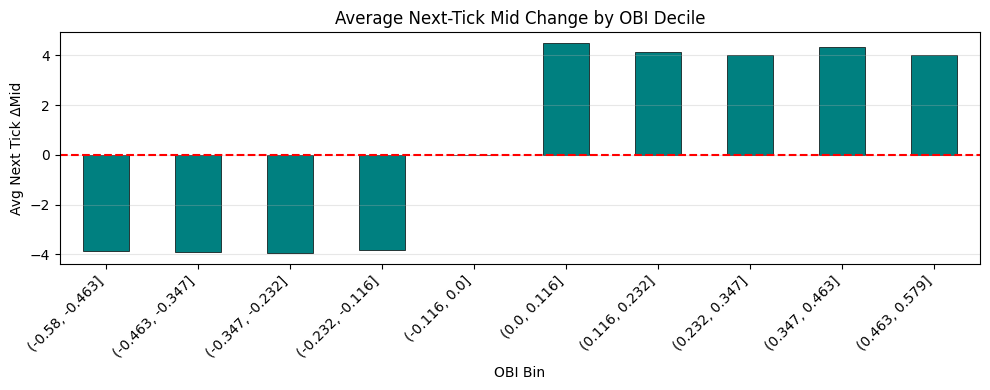

OBI → next tick correlation: 0.29888048601750034


In [9]:
# OBI predictive power
hg['next_mid_change'] = hg.groupby('day')['mid'].diff().shift(-1)
obi_bins = pd.cut(hg['obi'], bins=10)
predictive = hg.groupby(obi_bins, observed=True)['next_mid_change'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
predictive.plot(kind='bar', ax=ax, color='teal', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Average Next-Tick Mid Change by OBI Decile")
ax.set_xlabel("OBI Bin"); ax.set_ylabel("Avg Next Tick ΔMid")
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print("OBI → next tick correlation:", hg['obi'].corr(hg['next_mid_change']))

## 3. Intraday Patterns

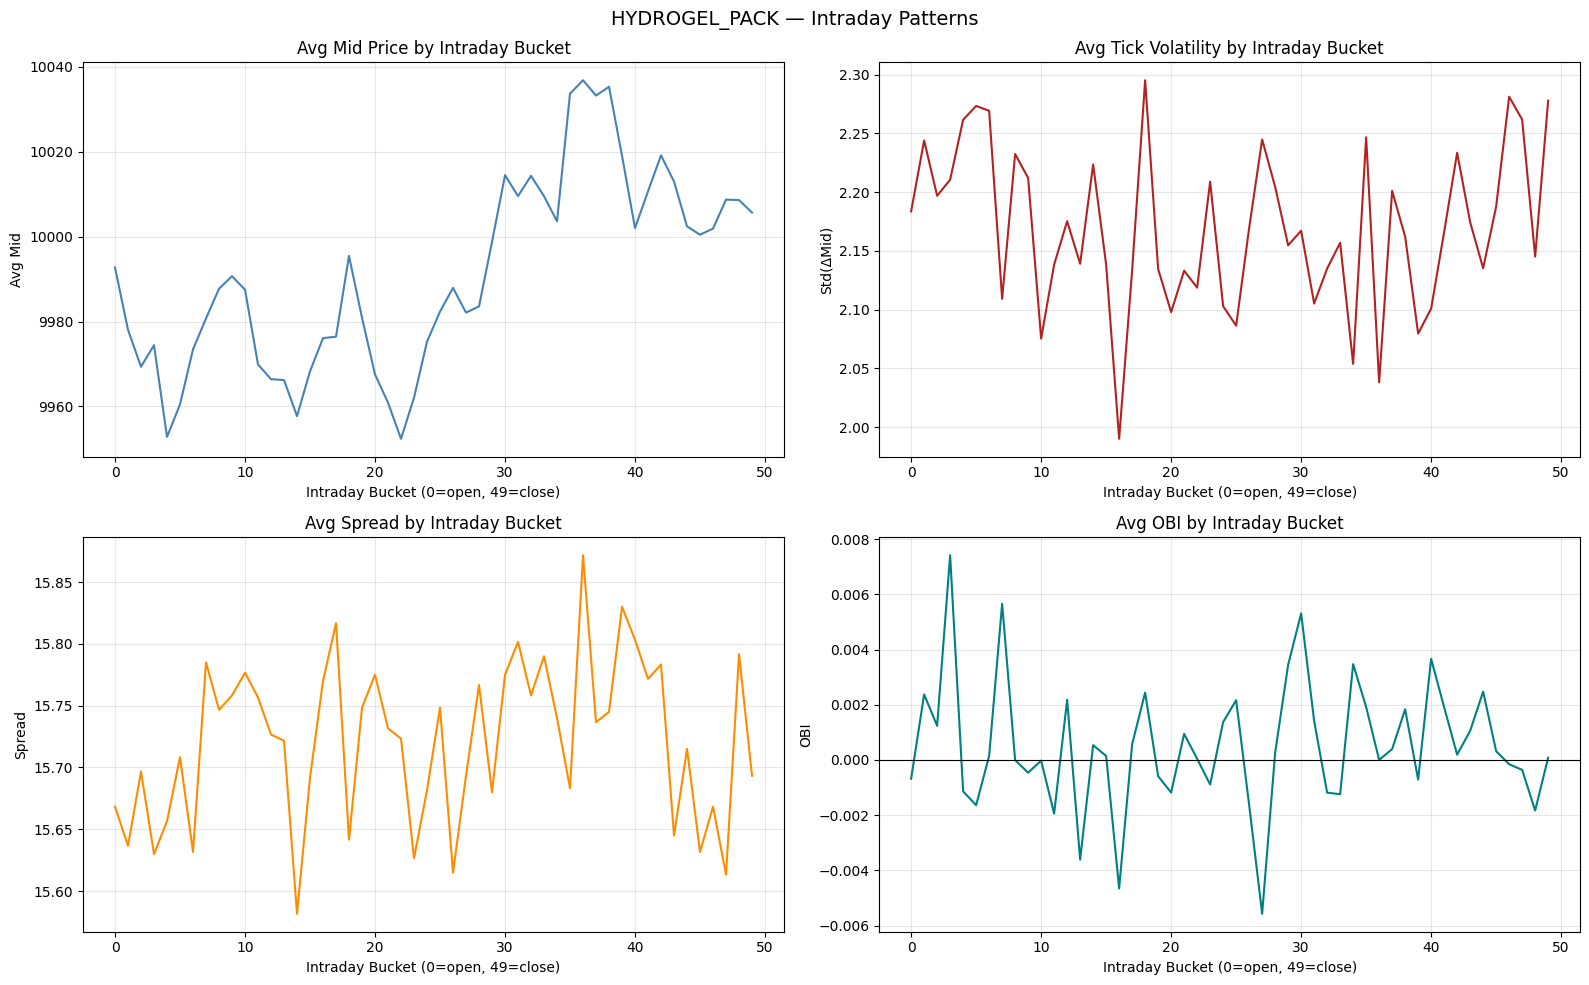

In [10]:
BINS = 50
hg['ts_bin'] = pd.cut(hg['timestamp'], bins=BINS, labels=False)

intraday_mid    = hg.groupby('ts_bin')['mid'].mean()
intraday_vol    = hg.groupby('ts_bin')['mid_return'].std()
intraday_spread = hg.groupby('ts_bin')['spread'].mean()
intraday_obi    = hg.groupby('ts_bin')['obi'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(intraday_mid.index, intraday_mid.values, color='steelblue', linewidth=1.5)
axes[0,0].set_title("Avg Mid Price by Intraday Bucket"); axes[0,0].set_ylabel("Avg Mid"); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(intraday_vol.index, intraday_vol.values, color='firebrick', linewidth=1.5)
axes[0,1].set_title("Avg Tick Volatility by Intraday Bucket"); axes[0,1].set_ylabel("Std(ΔMid)"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(intraday_spread.index, intraday_spread.values, color='darkorange', linewidth=1.5)
axes[1,0].set_title("Avg Spread by Intraday Bucket"); axes[1,0].set_ylabel("Spread"); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(intraday_obi.index, intraday_obi.values, color='teal', linewidth=1.5)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title("Avg OBI by Intraday Bucket"); axes[1,1].set_ylabel("OBI"); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Intraday Bucket (0=open, 49=close)")

plt.suptitle("HYDROGEL_PACK — Intraday Patterns", fontsize=14)
plt.tight_layout(); plt.show()

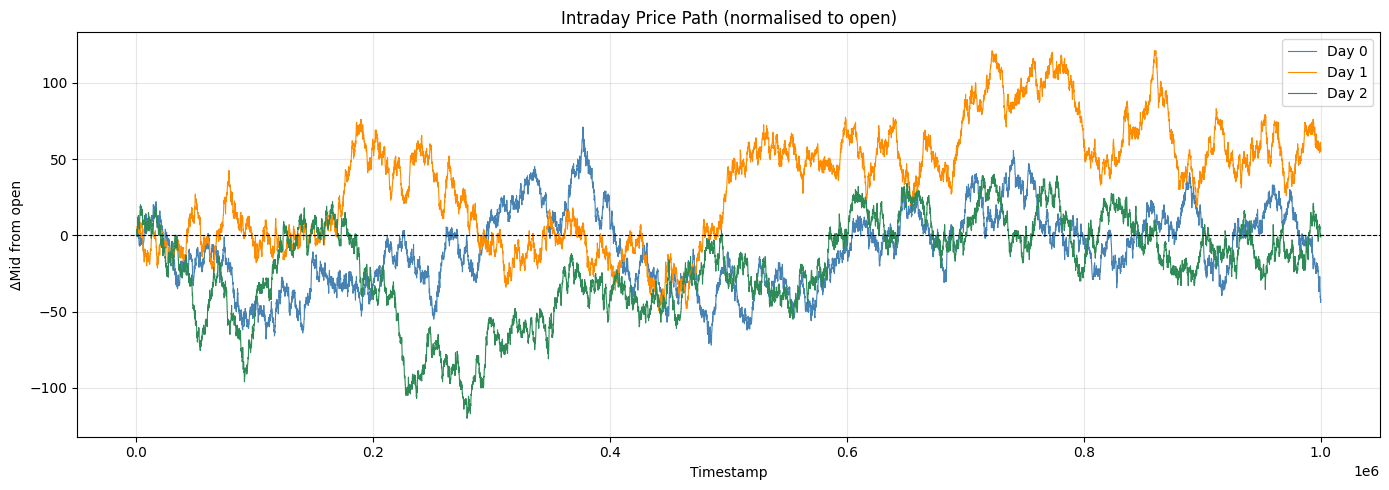

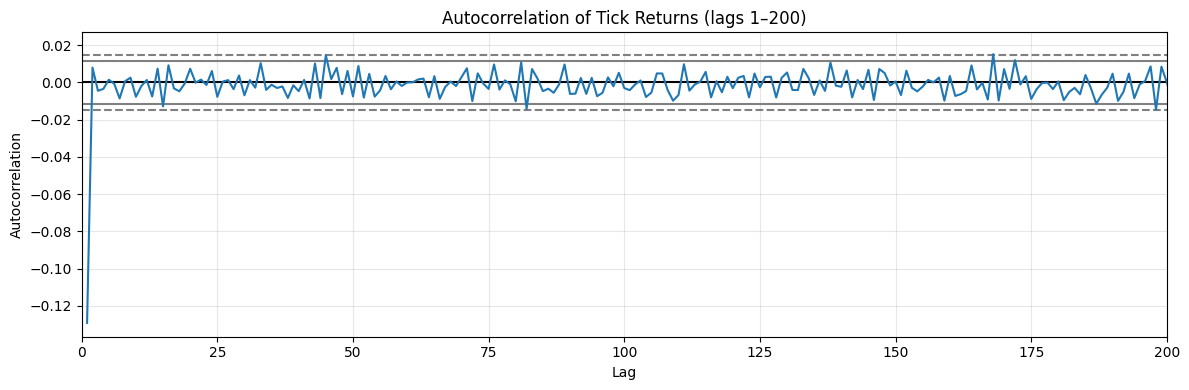

In [11]:
# Per-day normalised price path
fig, ax = plt.subplots(figsize=(14, 5))
for i, (day, df) in enumerate(sorted(hg_days.items())):
    normed = df['mid'].values - df['mid'].iloc[0]
    ax.plot(df['timestamp'].values, normed, linewidth=0.8, label=f"Day {day}", color=colors[i])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Intraday Price Path (normalised to open)")
ax.set_xlabel("Timestamp"); ax.set_ylabel("ΔMid from open")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Autocorrelation of returns
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(hg['mid_return'].dropna().reset_index(drop=True), ax=ax)
ax.set_xlim(0, 200)
ax.set_title("Autocorrelation of Tick Returns (lags 1–200)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Liquidity Analysis

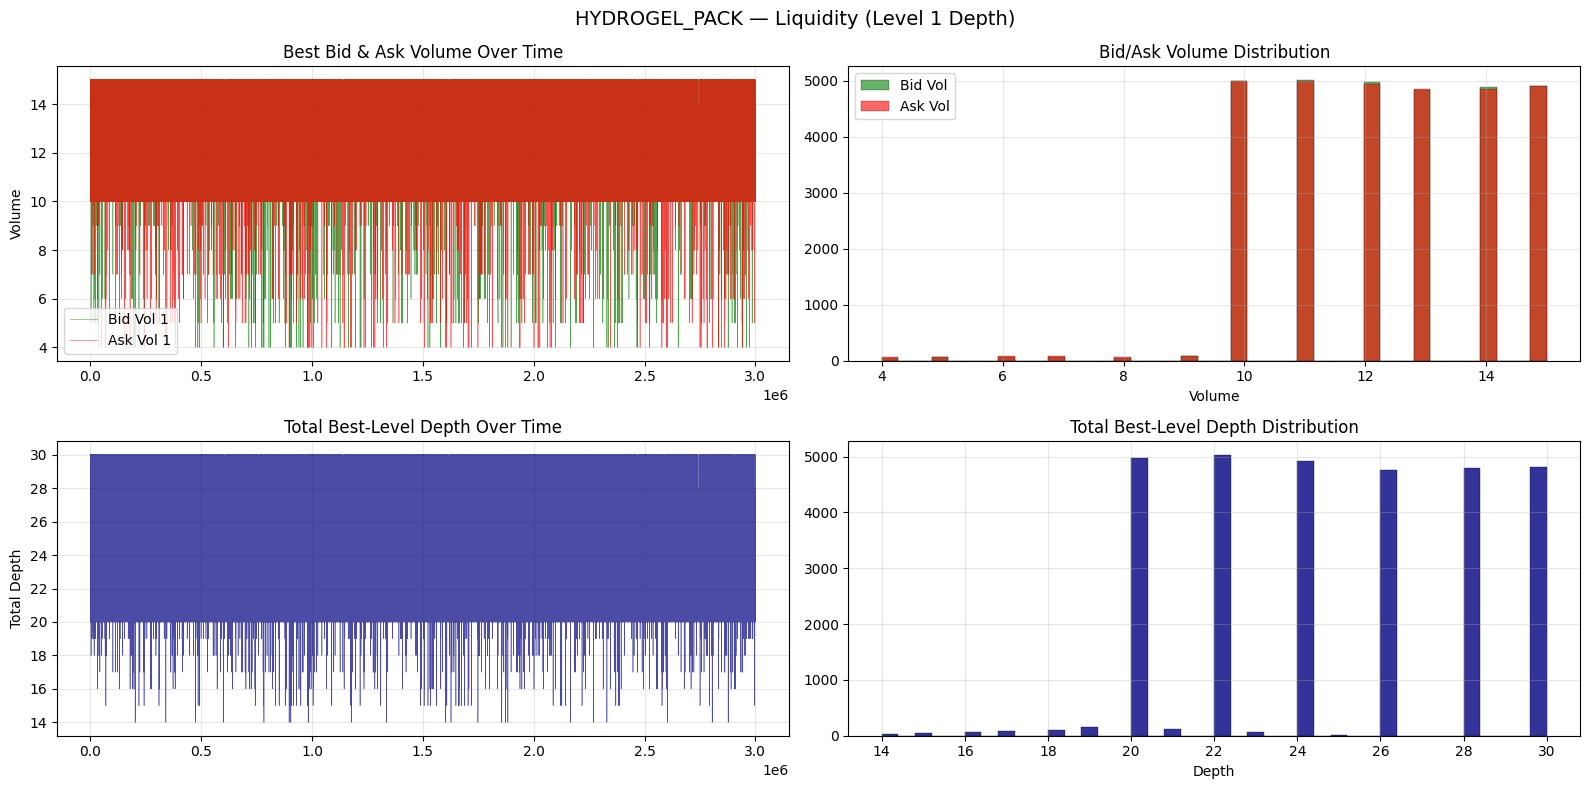

Bid volume 1 stats:
count    30000.000000
mean        12.404233
std          1.838389
min          4.000000
25%         11.000000
50%         12.000000
75%         14.000000
max         15.000000
Name: bid_volume_1, dtype: float64

Ask volume 1 stats:
count    30000.000000
mean        12.395033
std          1.854822
min          4.000000
25%         11.000000
50%         12.000000
75%         14.000000
max         15.000000
Name: ask_volume_1, dtype: float64


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].plot(hg['global_timestamp'], hg['bid_volume_1'], linewidth=0.4, color='green', alpha=0.7, label='Bid Vol 1')
axes[0,0].plot(hg['global_timestamp'], hg['ask_volume_1'], linewidth=0.4, color='red', alpha=0.7, label='Ask Vol 1')
axes[0,0].set_title("Best Bid & Ask Volume Over Time"); axes[0,0].set_ylabel("Volume"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(hg['bid_volume_1'].dropna(), bins=40, color='green', alpha=0.6, label='Bid Vol', edgecolor='black', linewidth=0.3)
axes[0,1].hist(hg['ask_volume_1'].dropna(), bins=40, color='red', alpha=0.6, label='Ask Vol', edgecolor='black', linewidth=0.3)
axes[0,1].set_title("Bid/Ask Volume Distribution"); axes[0,1].set_xlabel("Volume"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

hg['total_depth_1'] = hg['bid_volume_1'] + hg['ask_volume_1']
axes[1,0].plot(hg['global_timestamp'], hg['total_depth_1'], linewidth=0.4, color='navy', alpha=0.7)
axes[1,0].set_title("Total Best-Level Depth Over Time"); axes[1,0].set_ylabel("Total Depth"); axes[1,0].grid(alpha=0.3)

axes[1,1].hist(hg['total_depth_1'].dropna(), bins=40, color='navy', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1,1].set_title("Total Best-Level Depth Distribution"); axes[1,1].set_xlabel("Depth"); axes[1,1].grid(alpha=0.3)

plt.suptitle("HYDROGEL_PACK — Liquidity (Level 1 Depth)", fontsize=14)
plt.tight_layout(); plt.show()

print("Bid volume 1 stats:"); print(hg['bid_volume_1'].describe())
print("\nAsk volume 1 stats:"); print(hg['ask_volume_1'].describe())

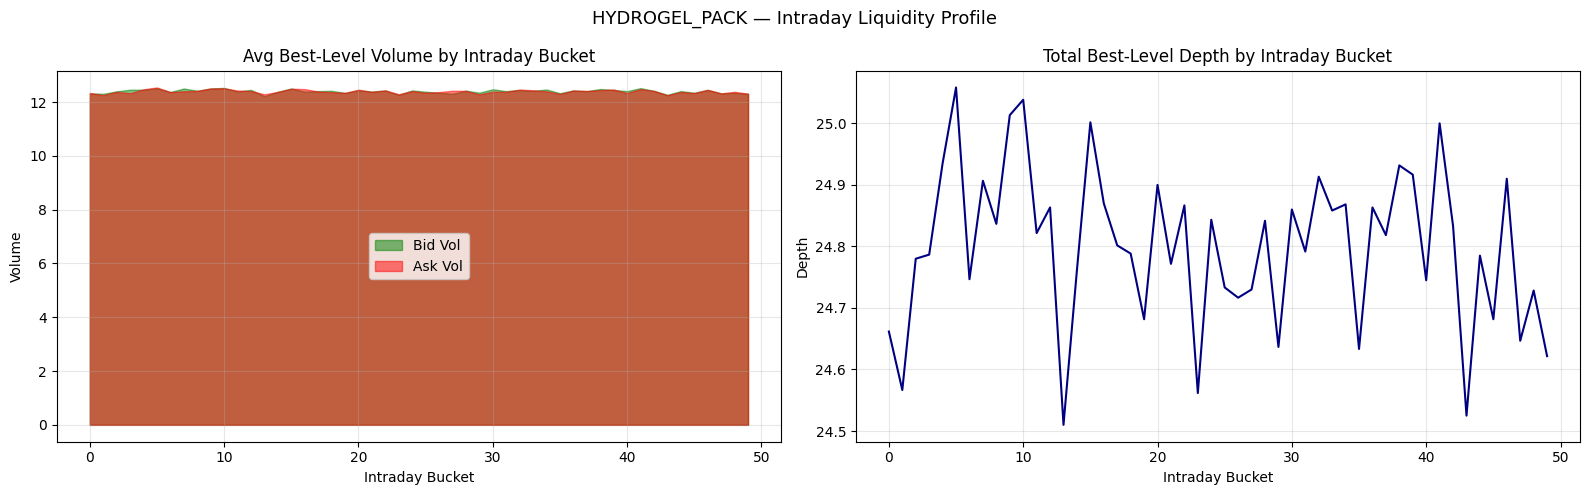

Effective spread (% of mid): mean=0.1574%, median=0.1600%
Estimated round-trip cost per unit (half-spread): 7.860 ticks


In [13]:
intraday_depth   = hg.groupby('ts_bin')['total_depth_1'].mean()
intraday_bid_vol = hg.groupby('ts_bin')['bid_volume_1'].mean()
intraday_ask_vol = hg.groupby('ts_bin')['ask_volume_1'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(intraday_bid_vol.index, intraday_bid_vol.values, alpha=0.5, color='green', label='Bid Vol')
axes[0].fill_between(intraday_ask_vol.index, intraday_ask_vol.values, alpha=0.5, color='red', label='Ask Vol')
axes[0].set_title("Avg Best-Level Volume by Intraday Bucket")
axes[0].set_xlabel("Intraday Bucket"); axes[0].set_ylabel("Volume"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(intraday_depth.index, intraday_depth.values, color='navy', linewidth=1.5)
axes[1].set_title("Total Best-Level Depth by Intraday Bucket")
axes[1].set_xlabel("Intraday Bucket"); axes[1].set_ylabel("Depth"); axes[1].grid(alpha=0.3)

plt.suptitle("HYDROGEL_PACK — Intraday Liquidity Profile", fontsize=13)
plt.tight_layout(); plt.show()

hg['eff_spread_pct'] = hg['spread'] / hg['mid'] * 100
print(f"Effective spread (% of mid): mean={hg['eff_spread_pct'].mean():.4f}%, median={hg['eff_spread_pct'].median():.4f}%")
print(f"Estimated round-trip cost per unit (half-spread): {hg['spread'].mean()/2:.3f} ticks")

## 5. Trade Data Analysis

In [14]:
trades_0['day'] = 0; trades_1['day'] = 1; trades_2['day'] = 2
trades_all = pd.concat([trades_0, trades_1, trades_2], ignore_index=True)
trades_all['global_timestamp'] = trades_all['timestamp'] + trades_all['day'] * 1_000_000

hg_trades = trades_all[trades_all['symbol'] == 'HYDROGEL_PACK'].copy().reset_index(drop=True)
print(f"Total HYDROGEL_PACK trades: {len(hg_trades)}")
print(f"\nColumns: {list(hg_trades.columns)}")
print(f"\nBuyer counts (top 10):\n{hg_trades['buyer'].value_counts().head(10)}")
print(f"\nSeller counts (top 10):\n{hg_trades['seller'].value_counts().head(10)}")
hg_trades.head()

Total HYDROGEL_PACK trades: 1010

Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day', 'global_timestamp']

Buyer counts (top 10):
Series([], Name: count, dtype: int64)

Seller counts (top 10):
Series([], Name: count, dtype: int64)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_timestamp
0,8000,NaN,NaN,HYDROGEL_PACK,XIRECS,10018.0,6,0,8000
1,10100,NaN,NaN,HYDROGEL_PACK,XIRECS,10014.0,5,0,10100
2,15300,NaN,NaN,HYDROGEL_PACK,XIRECS,10026.0,3,0,15300
3,15700,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,2,0,15700
4,16400,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,4,0,16400


ValueError: Invalid frequency: .

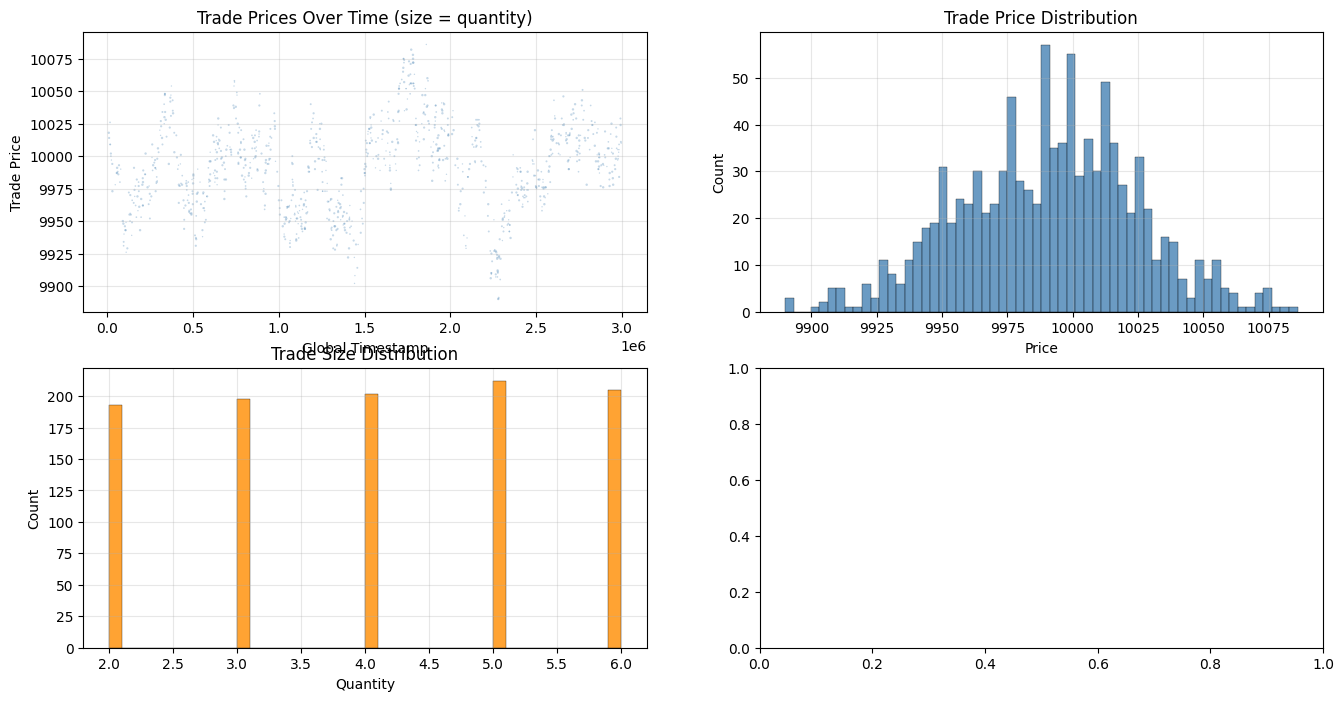

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].scatter(hg_trades['global_timestamp'], hg_trades['price'],
                  s=hg_trades['quantity']*0.5, alpha=0.3, color='steelblue', edgecolors='none')
axes[0,0].set_title("Trade Prices Over Time (size = quantity)")
axes[0,0].set_xlabel("Global Timestamp"); axes[0,0].set_ylabel("Trade Price"); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(hg_trades['price'], bins=60, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0,1].set_title("Trade Price Distribution")
axes[0,1].set_xlabel("Price"); axes[0,1].set_ylabel("Count"); axes[0,1].grid(alpha=0.3)

axes[1,0].hist(hg_trades['quantity'], bins=40, color='darkorange', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1,0].set_title("Trade Size Distribution")
axes[1,0].set_xlabel("Quantity"); axes[1,0].set_ylabel("Count"); axes[1,0].grid(alpha=0.3)

hg_trades_sorted = hg_trades.sort_values('global_timestamp')
trade_freq = hg_trades_sorted.set_index('global_timestamp')['quantity'].resample('').count()
trade_freq.plot(ax=axes[1,1], color='purple', linewidth=1)
axes[1,1].set_title("Trade Count per 100k Timestamp Interval")
axes[1,1].set_xlabel("Global Timestamp"); axes[1,1].set_ylabel("# Trades"); axes[1,1].grid(alpha=0.3)

plt.suptitle("HYDROGEL_PACK — Trade Analysis", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\nTrade size stats:\n{hg_trades['quantity'].describe()}")
print(f"\nTrade price stats:\n{hg_trades['price'].describe()}")

In [ ]:
top_buyers  = hg_trades['buyer'].value_counts().head(8)
top_sellers = hg_trades['seller'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_buyers.plot(kind='barh', ax=axes[0], color='green', edgecolor='black', linewidth=0.5)
axes[0].set_title("Top Buyers (trade count)"); axes[0].set_xlabel("# Trades"); axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_sellers.plot(kind='barh', ax=axes[1], color='red', edgecolor='black', linewidth=0.5)
axes[1].set_title("Top Sellers (trade count)"); axes[1].set_xlabel("# Trades"); axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("HYDROGEL_PACK — Market Participant Activity", fontsize=13)
plt.tight_layout(); plt.show()

buyer_vol  = hg_trades.groupby('buyer')['quantity'].sum().rename('bought')
seller_vol = hg_trades.groupby('seller')['quantity'].sum().rename('sold')
net_flow = pd.concat([buyer_vol, seller_vol], axis=1).fillna(0)
net_flow['net'] = net_flow['bought'] - net_flow['sold']
print("Net flow per participant (bought - sold):")
print(net_flow.sort_values('net', ascending=False).head(15))

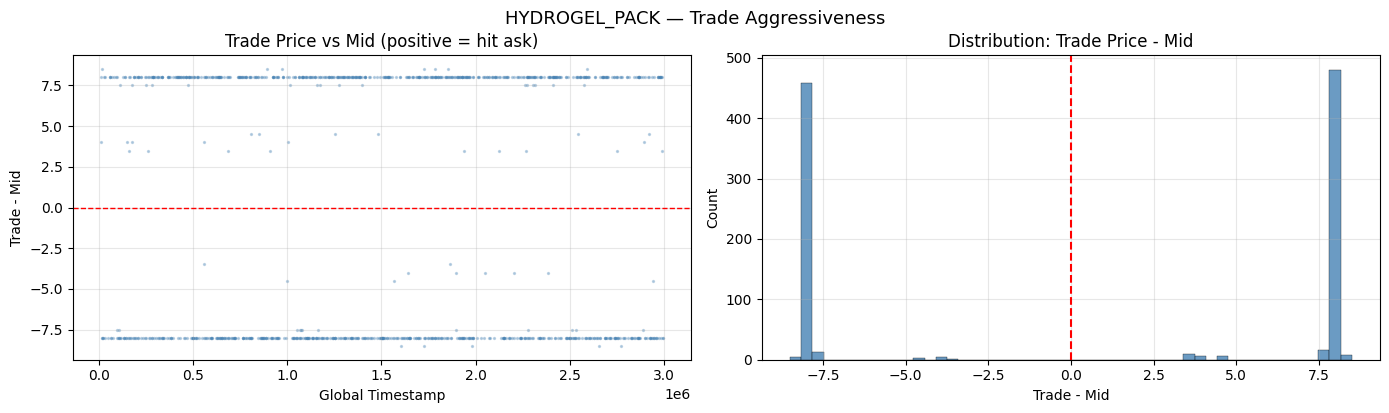

Trades hitting ask (aggressive buy): 51.9%
Trades hitting bid (aggressive sell): 48.1%
Trades at mid: 0.0%


In [20]:
hg_price_ref = hg[['day','timestamp','mid','bid_price_1','ask_price_1']].copy()
hg_trades_merged = hg_trades.merge(hg_price_ref, on=['day','timestamp'], how='left')
hg_trades_merged['trade_vs_mid'] = hg_trades_merged['price'] - hg_trades_merged['mid']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(hg_trades_merged['global_timestamp'], hg_trades_merged['trade_vs_mid'],
                s=2, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title("Trade Price vs Mid (positive = hit ask)")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("Trade - Mid"); axes[0].grid(alpha=0.3)

axes[1].hist(hg_trades_merged['trade_vs_mid'].dropna(), bins=50, color='steelblue',
             edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Distribution: Trade Price - Mid")
axes[1].set_xlabel("Trade - Mid"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("HYDROGEL_PACK — Trade Aggressiveness", y=1.02, fontsize=13)
plt.show()

buy_frac  = (hg_trades_merged['trade_vs_mid'] > 0).mean()
sell_frac = (hg_trades_merged['trade_vs_mid'] < 0).mean()
print(f"Trades hitting ask (aggressive buy): {buy_frac*100:.1f}%")
print(f"Trades hitting bid (aggressive sell): {sell_frac*100:.1f}%")
print(f"Trades at mid: {(1-buy_frac-sell_frac)*100:.1f}%")

## 6. Summary & Strategy Implications

In [21]:
print("=" * 55)
print("HYDROGEL_PACK — Analysis Summary")
print("=" * 55)

print(f"\n--- Price Behaviour ---")
print(f"  Mid price range:   {hg['mid'].min():.1f} – {hg['mid'].max():.1f}")
print(f"  Mid price mean:    {hg['mid'].mean():.2f}")
print(f"  Mid price std:     {hg['mid'].std():.2f}")
print(f"  Daily tick vol:    {hg.groupby('day')['mid_return'].std().to_dict()}")

print(f"\n--- Microstructure ---")
print(f"  Mean spread:       {hg['spread'].mean():.3f} ticks")
print(f"  Median spread:     {hg['spread'].median():.1f} ticks")
print(f"  Spread == 1:       {(hg['spread']==1).mean()*100:.1f}%")
print(f"  Mean OBI:          {hg['obi'].mean():.4f}")
print(f"  OBI std:           {hg['obi'].std():.4f}")
print(f"  OBI→price corr:    {hg['obi'].corr(hg['next_mid_change']):.4f}")

print(f"\n--- Liquidity ---")
print(f"  Mean bid depth 1:  {hg['bid_volume_1'].mean():.1f}")
print(f"  Mean ask depth 1:  {hg['ask_volume_1'].mean():.1f}")
print(f"  Half-spread cost:  {hg['spread'].mean()/2:.3f} ticks")

print(f"\n--- Trades ---")
print(f"  Total trades:      {len(hg_trades)}")
print(f"  Mean trade size:   {hg_trades['quantity'].mean():.1f}")
print(f"  Unique buyers:     {hg_trades['buyer'].nunique()}")
print(f"  Unique sellers:    {hg_trades['seller'].nunique()}")

print(f"\n--- Mean Reversion Signal ---")
print(f"  |Z| > 1:           {(hg['z_score'].abs() > 1).mean()*100:.1f}% of ticks")
print(f"  |Z| > 2:           {(hg['z_score'].abs() > 2).mean()*100:.1f}% of ticks")
print(f"  |Z| > 3:           {(hg['z_score'].abs() > 3).mean()*100:.1f}% of ticks")

HYDROGEL_PACK — Analysis Summary

--- Price Behaviour ---
  Mid price range:   9891.0 – 10079.0
  Mid price mean:    9990.81
  Mid price std:     31.94
  Daily tick vol:    {0: 2.1912194428594263, 1: 2.148322732939267, 2: 2.1699289638927475}

--- Microstructure ---
  Mean spread:       15.721 ticks
  Median spread:     16.0 ticks
  Spread == 1:       0.0%
  Mean OBI:          0.0005
  OBI std:           0.0579
  OBI→price corr:    0.2989

--- Liquidity ---
  Mean bid depth 1:  12.4
  Mean ask depth 1:  12.4
  Half-spread cost:  7.860 ticks

--- Trades ---
  Total trades:      1010
  Mean trade size:   4.0
  Unique buyers:     0
  Unique sellers:    0

--- Mean Reversion Signal ---
  |Z| > 1:           53.9% of ticks
  |Z| > 2:           14.4% of ticks
  |Z| > 3:           1.1% of ticks
